# Hypothesis testing by simulation

**How to use this notebook:** run cells **top to bottom**. Read the markdown **before** each code cell. Animations appear **inline** (HTML); if one does not show, run the cell again.

We go **slowly**: Part 1 uses a classroom true/false story; Part 2 repeats the *same logic* for a regression slope, with **animations** linking “one dataset” → “many datasets” → “histogram”; **Part 3** builds confidence intervals for a normal mean (known then unknown $\sigma$) and stresses the **long-run frequency** meaning of a confidence level.

Companion read: [Hypothesis Testing: (Almost) Everything you need to know](https://medium.com/@gallettilance/hypothesis-testing-almost-everything-you-need-to-know-ce812ded50b).

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
from scipy.stats import norm, t

rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (7, 4)
# Allow larger embedded animations in the notebook (megabytes)
plt.rcParams["animation.embed_limit"] = 50


## 1. A true/false question: did the class learn?

**Slow down:** each subsection adds *one* new idea. If a plot looks busy, focus on **one color** (coral = “extreme under the null”).

You give one true/false question about linear regression. Each student either gets it right or wrong.

**Working model.** We simulate each student as an independent **Bernoulli** trial: “correct” with probability $p$. For a class of $n$ students, we count how many answer correctly and call that $X$.

We never observe $p$ directly; we only see $X$ (or the proportion $X/n$).

**Guessing benchmark.** If students are *only* guessing, we simulate with $p = \tfrac{1}{2}$. We want the class to do **better than 50%** to believe they are not just flipping mental coins—but *how much* better depends on **class size** and on what we count as “extreme” (**alternative hypothesis**).

Below we rely on **simulations only**: histograms, colored tail regions, and **simulated p-values** (fraction of null draws at least as extreme as what we saw)—no textbook probability curves.

### 1.1 Start small: $n = 5$ students

**What to look for:** three bar charts with **different shapes**. Same machinery (5 Bernoulli students per class); only $p$ changes.

**Setup.** Many imaginary **classes**. Each class: **5 students**, each independently “correct” with probability $p$. One row of 0/1 draws per class; $X$ = count correct.

Three worlds:

- **Most understand:** $p = 0.85$
- **Guessing:** $p = 0.5$
- **Most misunderstand:** $p = 0.15$

For each world we run `N_SIM` classes and plot the **simulated** distribution of $X$. Compare shapes: high $p$ piles mass on high counts; guessing is centered; low $p$ piles mass on low counts.

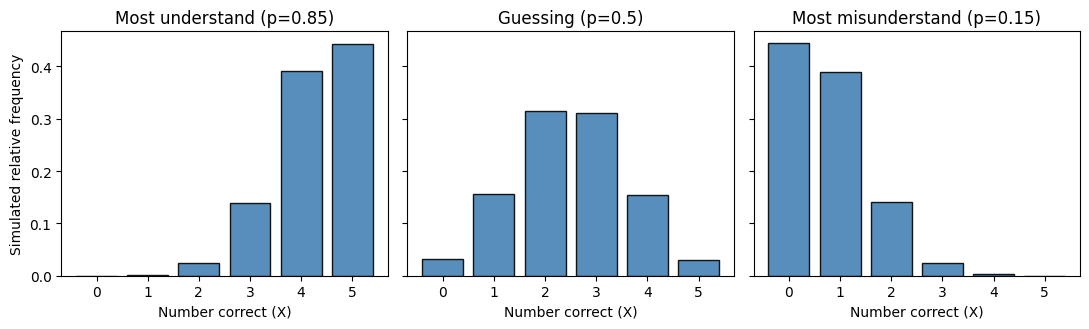

8 simulated classes under guessing (rows = classes, cols = 5 students; 1 = correct):
[[0 1 1 0 1]
 [0 1 1 1 1]
 [0 1 0 0 1]
 [1 0 0 1 0]
 [1 0 0 0 0]
 [1 0 0 1 0]
 [1 0 1 1 1]
 [0 1 0 0 0]]
Number correct per class: [3 4 2 2 1 2 4 1]


In [5]:
n_small = 5
ks = np.arange(0, n_small + 1)
N_SIM = 50_000
sim_rng = np.random.default_rng(12345)

worlds = {
    "Most understand (p=0.85)": 0.85,
    "Guessing (p=0.5)": 0.50,
    "Most misunderstand (p=0.15)": 0.15,
}

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharey=True)
for ax, (name, p) in zip(axes, worlds.items()):
    student_correct = sim_rng.binomial(1, p, size=(N_SIM, n_small))
    correct_per_class = student_correct.sum(axis=1)
    sim_freq = np.bincount(correct_per_class, minlength=n_small + 1) / N_SIM

    ax.bar(ks, sim_freq, color="steelblue", edgecolor="black", alpha=0.9)
    ax.set_xticks(ks)
    ax.set_xlabel("Number correct (X)")
    ax.set_title(name)

axes[0].set_ylabel("Simulated relative frequency")
plt.tight_layout()
plt.show()

p_show = 0.5
demo = sim_rng.binomial(1, p_show, size=(8, n_small))
print("8 simulated classes under guessing (rows = classes, cols = 5 students; 1 = correct):")
print(demo)
print("Number correct per class:", demo.sum(axis=1))

### 1.2 “Exactly this many correct” gets rarer as $n$ grows

**What to look for:** the plotted points **fall** toward zero as $n$ increases. That is why we will care about **tails**, not one exact bar.

Fix **guessing** ($p = 0.5$). For several class sizes $n$, we simulate many classes and record how often $X$ equals $k^* = \mathrm{round}(0.4n)$ (so the **proportion** stays near 0.4).

The curve falls toward zero as $n$ grows: one **exact** outcome is a weaker story than **tail** evidence. The next section colors those tails under $H_0$.

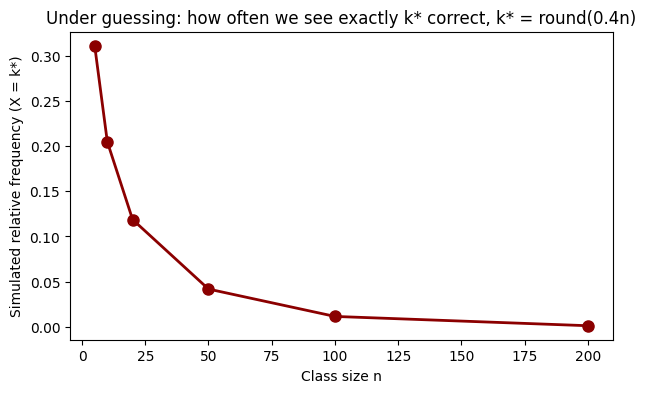

n=  5, k*=  2: simulated freq. (X = k*) = 0.31117
n= 10, k*=  4: simulated freq. (X = k*) = 0.20475
n= 20, k*=  8: simulated freq. (X = k*) = 0.11868
n= 50, k*= 20: simulated freq. (X = k*) = 0.04175
n=100, k*= 40: simulated freq. (X = k*) = 0.01145
n=200, k*= 80: simulated freq. (X = k*) = 0.00117


In [6]:
p0 = 0.5
ns = np.array([5, 10, 20, 50, 100, 200])
N_PER = 60_000
rng_exact = np.random.default_rng(777)

sim_freq_exact = []
for n in ns:
    k_star = int(round(0.4 * n))
    x = rng_exact.binomial(1, p0, size=(N_PER, n)).sum(axis=1)
    sim_freq_exact.append(np.mean(x == k_star))

fig, ax = plt.subplots()
ax.plot(ns, sim_freq_exact, "o-", color="darkred", lw=2, markersize=8)
ax.set_xlabel("Class size n")
ax.set_ylabel("Simulated relative frequency (X = k*)")
ax.set_title("Under guessing: how often we see exactly k* correct, k* = round(0.4n)")
plt.show()

for n, f in zip(ns, sim_freq_exact):
    k_star = int(round(0.4 * n))
    print(f"n={n:3d}, k*={k_star:3d}: simulated freq. (X = k*) = {f:.5f}")

### 1.3 Visual evidence under the null (guessing)

**What to look for:** **coral** bars are the “extreme” region; the **navy** line is what we actually saw (4/5). The title prints a **simulated p-value** ≈ coral area.

**Null $H_0$:** simulate classes with $p = 0.5$.

**Alternative $H_1$** picks which outcomes count as “extreme”:

1. **Two-sided** (not “purely random” in either direction): counts far from $n/2$ in **either** direction.
2. **One-sided** (evidence of doing **better** than guessing): only high counts.

We observe **4 correct out of 5**. The plots show the **null histogram** with **coral** bars for outcomes at least as extreme as 4 under each rule, a **navy** line at the observed $X$, and **simulated p-value** = fraction of null draws landing in coral.

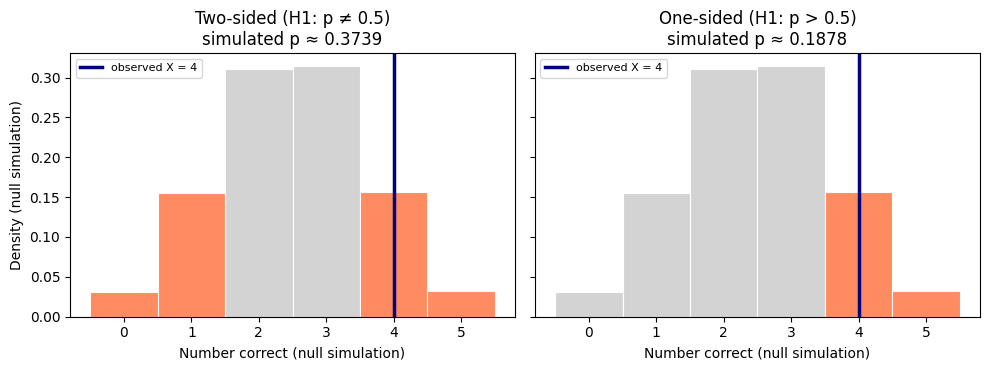

Extreme counts (two-sided): [0, 1, 4, 5]
Simulated two-sided p-value: 0.37388
Simulated one-sided p-value: 0.18782


In [7]:
n = 5
x_obs = 4
p0 = 0.5
N_NULL = 120_000
rng_null = np.random.default_rng(11)

x_null = rng_null.binomial(1, p0, size=(N_NULL, n)).sum(axis=1)
center = n * p0
dev_obs = abs(x_obs - center)

extreme_two = {k for k in range(n + 1) if abs(k - center) >= dev_obs}
extreme_one = {k for k in range(n + 1) if k >= x_obs}

mask_two = np.isin(x_null, list(extreme_two))
mask_one = np.isin(x_null, list(extreme_one))
p_two_sim = mask_two.mean()
p_one_sim = mask_one.mean()

bins = np.arange(-0.5, n + 1.5, 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)

for ax, extreme_set, title, pval in zip(
    axes,
    [extreme_two, extreme_one],
    ["Two-sided (H1: p ≠ 0.5)", "One-sided (H1: p > 0.5)"],
    [p_two_sim, p_one_sim],
):
    counts, edges, patches = ax.hist(
        x_null,
        bins=bins,
        density=True,
        color="lightgray",
        edgecolor="white",
        linewidth=0.8,
    )
    for patch, left in zip(patches, edges[:-1]):
        k = int(left + 0.5)
        if k in extreme_set:
            patch.set_facecolor("coral")
            patch.set_alpha(0.9)
    ax.axvline(x_obs, color="navy", lw=2.5, label=f"observed X = {x_obs}")
    ax.set_xlabel("Number correct (null simulation)")
    ax.set_title(f"{title}\nsimulated p ≈ {pval:.4f}")
    ax.set_xticks(range(n + 1))
    ax.legend(fontsize=8)

axes[0].set_ylabel("Density (null simulation)")
plt.tight_layout()
plt.show()

print("Extreme counts (two-sided):", sorted(extreme_two))
print(f"Simulated two-sided p-value: {p_two_sim:.5f}")
print(f"Simulated one-sided p-value: {p_one_sim:.5f}")

### 1.4 Same proportion, bigger class: stronger visual evidence

**What to look for:** same **80%** correct as before in terms of proportion, but the navy line now sits in a **skinnier** histogram—so the coral tail area (simulated $p$) **shrinks**.

**40 correct out of 50** is again $\hat p = 0.8$. Under the same null (guessing), we simulate $X$ for $n=50$ and color the two-sided tail. The observed count sits farther into the tail than for $n=5$, so the **simulated p-value** (coral area) shrinks dramatically even though the **proportion** matched the earlier example.

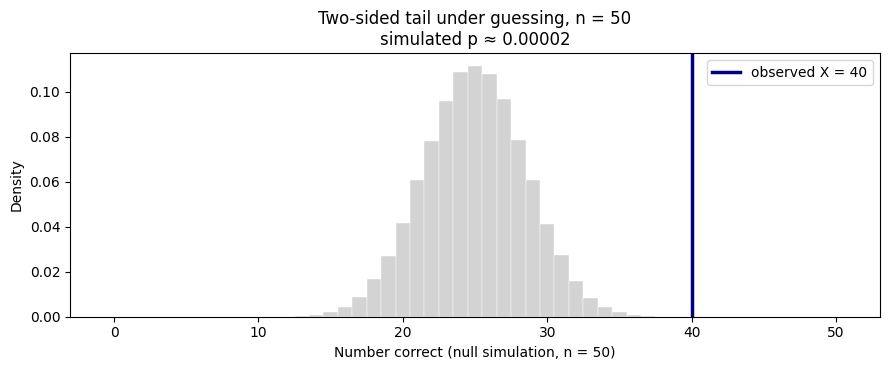

Observed: 40/50 correct (proportion 0.80)
Simulated two-sided p-value: 0.00002


In [8]:
n2 = 50
x_obs2 = 40
p0 = 0.5
N_NULL2 = 120_000
rng_n50 = np.random.default_rng(33)

x_null2 = rng_n50.binomial(1, p0, size=(N_NULL2, n2)).sum(axis=1)
center2 = n2 * p0
dev2 = abs(x_obs2 - center2)
extreme_two2 = {k for k in range(n2 + 1) if abs(k - center2) >= dev2}
mask2 = np.isin(x_null2, list(extreme_two2))
p_two_sim2 = mask2.mean()

bins2 = np.arange(-0.5, n2 + 1.5, 1)
fig, ax = plt.subplots(figsize=(9, 3.8))
counts, edges, patches = ax.hist(
    x_null2,
    bins=bins2,
    density=True,
    color="lightgray",
    edgecolor="white",
    linewidth=0.3,
)
for patch, left in zip(patches, edges[:-1]):
    k = int(left + 0.5)
    if 0 <= k <= n2 and k in extreme_two2:
        patch.set_facecolor("coral")
        patch.set_alpha(0.85)

ax.axvline(x_obs2, color="navy", lw=2.5, label=f"observed X = {x_obs2}")
ax.set_xlabel("Number correct (null simulation, n = 50)")
ax.set_ylabel("Density")
ax.set_title(f"Two-sided tail under guessing, n = 50\nsimulated p ≈ {p_two_sim2:.5f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Observed: {x_obs2}/{n2} correct (proportion {x_obs2/n2:.2f})")
print(f"Simulated two-sided p-value: {p_two_sim2:.5f}")

---

## 2. Linear regression — very slow walk (simulation + animations)

In Part 1, each **class** was a draw from a simple random story (students pass/fail). In Part 2, each **dataset** is a draw: we pick some $x$ values, pick some $y$ values, and run ordinary least squares (OLS) to get a **fitted line** and an **estimated slope** $\hat\beta_1$.

**The uncomfortable fact:** OLS **always** draws a line through the cloud, even when $x$ and $y$ are unrelated. So we need a **reference distribution**: “if there were *no* real slope, how much would $\hat\beta_1$ wiggle just from noise?”

We build that reference **only with simulations**—and we use **animations** so you can *see* one dataset at a time turning into many datasets, then into a **histogram**.

**Suggested pace:** run each cell in order. Wait for animations to finish; re-run a cell if you want another random path.

### Step 1 — Tie the story to regression (no code yet)

| Part 1 (classroom) | Part 2 (regression) |
|--------------------|---------------------|
| One **class** → count correct $X$ | One **dataset** → estimated slope $\hat\beta_1$ |
| Null: **guessing** ($p=\tfrac12$) | Null: **no linear link** (we simulate $y$ as pure noise after fixing $x$) |
| “Extreme” count → evidence | “Extreme” $\hat\beta_1$ (or $t$) → evidence |

We never see the true world; we only see **one** dataset. The question is always: **is what we saw a common null outcome, or a rare tail?**

### Step 2 — One **null** dataset: noise only, but still a line

**Null world here:** the **true** slope is **0**. We still pick $x$ values in $[-1,1]$, but $y$ is **only** random noise (mean 0)—**not** a linear function of $x$.

**OLS anyway:** the algorithm finds the “best” intercept and slope for *this* cloud. That slope $\hat\beta_1$ is almost never *exactly* zero, even when the truth is “no relationship.”

Run the next cell. Read the printed $\hat\beta_1$. **Remember:** this number is partly **luck**.

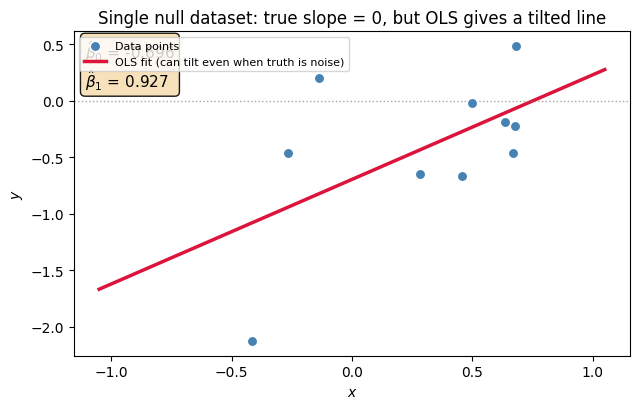

Estimated intercept: -0.6962265739474593
Estimated slope: 0.9268687241704077


In [9]:
SAMPLE_SIZE = 10
step2_rng = np.random.default_rng(202601)

x_one = -1.0 + 2.0 * step2_rng.random(SAMPLE_SIZE)
y_one = step2_rng.standard_normal(SAMPLE_SIZE)

X_one = np.column_stack([np.ones(SAMPLE_SIZE), x_one])
beta_one = np.linalg.inv(X_one.T @ X_one) @ X_one.T @ y_one
b0, b1 = float(beta_one[0]), float(beta_one[1])

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.scatter(x_one, y_one, s=55, c="steelblue", edgecolors="white", zorder=3, label="Data points")
xx = np.linspace(-1.05, 1.05, 80)
ax.plot(xx, b0 + b1 * xx, color="crimson", lw=2.5, label="OLS fit (can tilt even when truth is noise)")
ax.axhline(0, color="gray", ls=":", lw=1, alpha=0.7)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title("Single null dataset: true slope = 0, but OLS gives a tilted line")
ax.legend(loc="upper left", fontsize=8)
ax.text(
    0.02,
    0.98,
    rf"$\hat{{\beta}}_0$ = {b0:.3f}" + "\n" + rf"$\hat{{\beta}}_1$ = {b1:.3f}",
    transform=ax.transAxes,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.9),
)
plt.tight_layout()
plt.show()

print("Estimated intercept:", b0)
print("Estimated slope:", b1)

### Step 3 — Six **different** null datasets (static collage)

Same rules every time: **true slope 0**, new random noise. Each panel is an independent “parallel universe.”

Notice: the **line tilts a different way** each time. None of this requires a real relationship—**pure noise** can look sloped in a small sample.

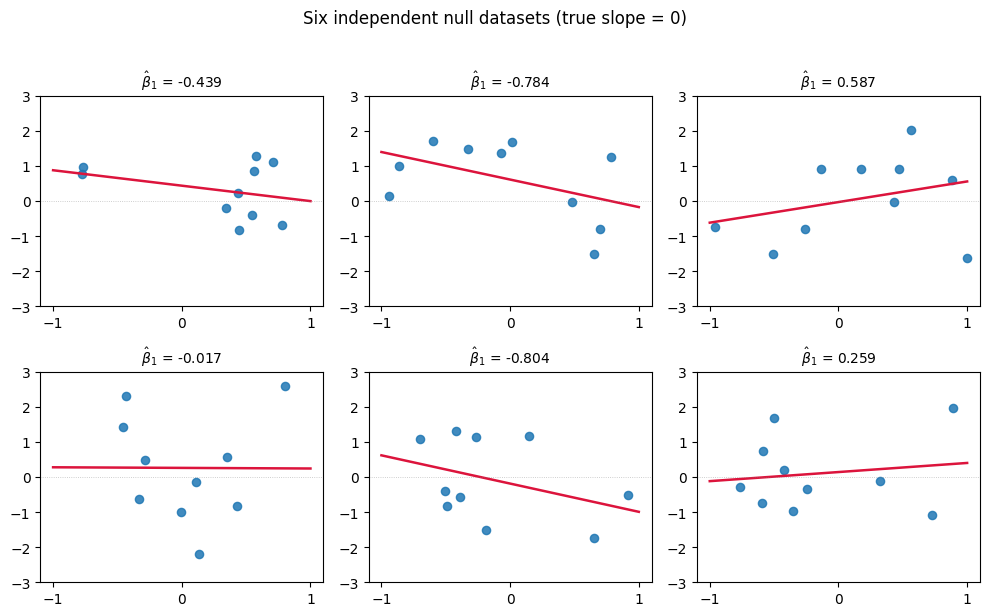

In [10]:
grid_rng = np.random.default_rng(202602)
SAMPLE_SIZE = 10
n_panels = 6

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.ravel()
for ax in axes:
    xv = -1.0 + 2.0 * grid_rng.random(SAMPLE_SIZE)
    yv = grid_rng.standard_normal(SAMPLE_SIZE)
    Xv = np.column_stack([np.ones(SAMPLE_SIZE), xv])
    bv = np.linalg.inv(Xv.T @ Xv) @ Xv.T @ yv
    ax.scatter(xv, yv, s=35, alpha=0.85)
    xs = np.linspace(-1, 1, 40)
    ax.plot(xs, bv[0] + bv[1] * xs, color="crimson", lw=1.8)
    ax.set_title(rf"$\hat{{\beta}}_1$ = {bv[1]:.3f}", fontsize=10)
    ax.set_xticks([-1, 0, 1])
    ax.set_ylim(-3, 3)
    ax.axhline(0, color="gray", ls=":", lw=0.6, alpha=0.5)

fig.suptitle("Six independent null datasets (true slope = 0)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Step 4 — **Animation:** one null world after another

Each frame = **new** $x$’s, **new** noise $y$, **new** OLS line. Nothing here is “learning” or a true trend—it is **the null story** told many times.

If the animation is small, use the notebook zoom. **Re-run** the cell to watch a different random sequence.

In [11]:
ANIM_N = 36
ANIM_SAMPLE = 10
arng = np.random.default_rng(202603)

xs_anim = []
ys_anim = []
for _ in range(ANIM_N):
    xa = -1.0 + 2.0 * arng.random(ANIM_SAMPLE)
    ya = arng.standard_normal(ANIM_SAMPLE)
    xs_anim.append(xa)
    ys_anim.append(ya)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
scatter = ax.scatter([], [], s=50, c="steelblue", edgecolors="white", zorder=3)
(line_anim,) = ax.plot([], [], color="crimson", lw=2.2)

ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-3.2, 3.2)
ax.axhline(0, color="gray", ls=":", lw=0.8, alpha=0.6)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")


def animate_frame(i):
    xa, ya = xs_anim[i], ys_anim[i]
    Xa = np.column_stack([np.ones(ANIM_SAMPLE), xa])
    b = np.linalg.inv(Xa.T @ Xa) @ Xa.T @ ya
    scatter.set_offsets(np.column_stack([xa, ya]))
    xf = np.linspace(-1, 1, 60)
    line_anim.set_data(xf, b[0] + b[1] * xf)
    ax.set_title(
        f"Null simulation — trial {i + 1}/{ANIM_N}\n"
        rf"$\hat{{\beta}}_1$ = {b[1]:.3f}  (truth = 0)"
    )
    return (scatter, line_anim)


anim_line = animation.FuncAnimation(
    fig,
    animate_frame,
    frames=ANIM_N,
    interval=280,
    blit=False,
)
plt.close(fig)
display(HTML(anim_line.to_jshtml()))

### Step 5 — **Animation:** the histogram **fills up** with slopes

Now we **ignore the pictures** of clouds and only keep the number $\hat\beta_1$ from each null dataset.

Early frames: the histogram is **sparse** and lumpy. Later: it **stabilizes** into a bell-like mound centered near **0**—that mound *is* the null reference for “no relationship.”

(Technical note you can ignore on first read: the exact shape depends on how we sample $x$ and the sample size; the *idea* is always “repeat the null story many times.”)

In [17]:
HIST_PRE = 200
hrng = np.random.default_rng(202604)
SAMPLE_SIZE = 10

slopes_hist = []
for _ in range(HIST_PRE):
    xh = -1.0 + 2.0 * hrng.random(SAMPLE_SIZE)
    yh = hrng.standard_normal(SAMPLE_SIZE)
    Xh = np.column_stack([np.ones(SAMPLE_SIZE), xh])
    bh = np.linalg.inv(Xh.T @ Xh) @ Xh.T @ yh
    slopes_hist.append(bh[1])
slopes_hist = np.array(slopes_hist)

fig2, ax2 = plt.subplots(figsize=(7.5, 4.2))
bin_edges = np.linspace(-3.5, 3.5, 22)


def animate_hist(i):
    ax2.clear()
    n_show = i + 1
    ax2.hist(
        slopes_hist[:n_show],
        bins=bin_edges,
        color="steelblue",
        edgecolor="white",
        alpha=0.88,
        density=True,
    )
    ax2.axvline(0, color="black", ls="--", lw=1.2, label="True slope (null)")
    ax2.set_xlim(-3.5, 3.5)
    ax2.set_ylim(0, None)
    ax2.set_xlabel(r"Estimated slope $\hat{\beta}_1$ (null worlds)")
    ax2.set_ylabel("Density")
    ax2.set_title(f"Accumulated null slopes: {n_show} / {HIST_PRE} datasets")
    ax2.legend(loc="upper right", fontsize=8)
    return ()


anim_hist = animation.FuncAnimation(
    fig2,
    animate_hist,
    frames=HIST_PRE,
    interval=120,
    blit=False,
)
plt.close(fig2)
display(HTML(anim_hist.to_jshtml()))

### Step 6 — **Many** null slopes at once + your “signal” comparison

We now run **tens of thousands** of null datasets (fast, no animation). The histogram is smooth. Then we draw **one** dataset where the truth **does** have a positive slope (`y = 5x + noise`) with a fixed random seed so you can reproduce it.

**Coral** = null outcomes at least as far from 0 as your signal slope (**two-sided**). The **simulated p-value** is “what fraction of null slopes landed in coral?”

If that fraction is **tiny**, the signal slope is in a **rare** null tail—intuitively, strong evidence **against** “noise only.”

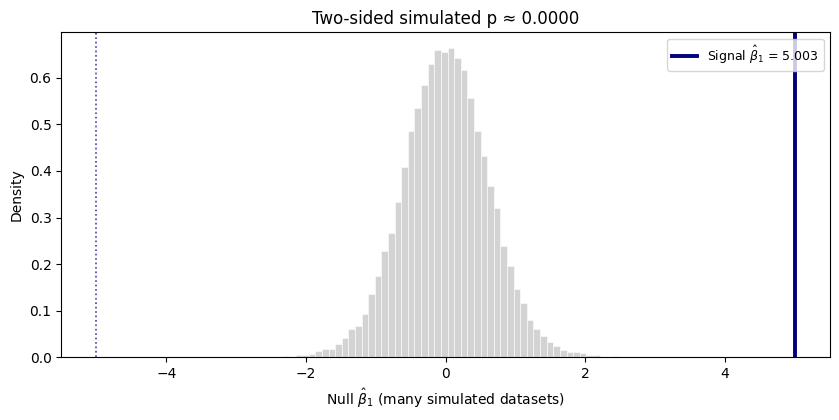

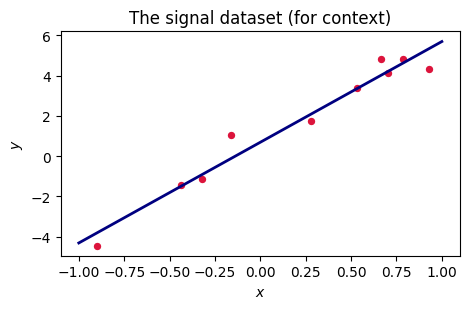

In [13]:
NUM_TRIALS = 40_000
SAMPLE_SIZE = 10
rng_null = np.random.default_rng(2026)

slopes = []
for _ in range(NUM_TRIALS):
    xlin = -1.0 + 2.0 * rng_null.random(SAMPLE_SIZE)
    y = rng_null.standard_normal(SAMPLE_SIZE)
    X = np.column_stack([np.ones(SAMPLE_SIZE), xlin])
    b = np.linalg.inv(X.T @ X) @ X.T @ y
    slopes.append(b[1])
slopes = np.array(slopes)

# Same "signal" sample as before (reproducible)
rng_lr = np.random.default_rng(94290)
x_sig = -1.0 + 2.0 * rng_lr.random(SAMPLE_SIZE)
y_sig = 5.0 * x_sig + rng_lr.standard_normal(SAMPLE_SIZE)
X_sig = np.column_stack([np.ones(SAMPLE_SIZE), x_sig])
beta_sig = np.linalg.inv(X_sig.T @ X_sig) @ X_sig.T @ y_sig
obs_slope = float(beta_sig[1])

dev = abs(obs_slope)
mask = np.abs(slopes) >= dev
p_sim_slope = mask.mean()

fig, ax = plt.subplots(figsize=(8.5, 4.3))
counts, edges, patches = ax.hist(
    slopes, bins=80, density=True, color="lightgray", edgecolor="white", linewidth=0.4
)
centers = 0.5 * (edges[:-1] + edges[1:])
for patch, c in zip(patches, centers):
    if abs(c) >= dev:
        patch.set_facecolor("coral")
        patch.set_alpha(0.88)

ax.axvline(obs_slope, color="navy", lw=2.8, label=rf"Signal $\hat{{\beta}}_1$ = {obs_slope:.3f}")
ax.axvline(-obs_slope, color="navy", lw=1.2, ls=":", alpha=0.75)
ax.set_xlabel(r"Null $\hat{\beta}_1$ (many simulated datasets)")
ax.set_ylabel("Density")
ax.set_title(f"Two-sided simulated p ≈ {p_sim_slope:.4f}")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

# Small inset: the signal dataset
figb, axb = plt.subplots(figsize=(4.8, 3.2))
axb.scatter(x_sig, y_sig, c="crimson", edgecolors="white", s=40)
xx = np.linspace(-1, 1, 60)
axb.plot(xx, beta_sig[0] + beta_sig[1] * xx, color="navy", lw=2)
axb.set_title("The signal dataset (for context)")
axb.set_xlabel(r"$x$")
axb.set_ylabel(r"$y$")
plt.tight_layout()
plt.show()

### Step 7 — Why **standard error** matters (spread, $n$, and unknown $\sigma$)

**Big picture.** Under the **null** (no real slope), OLS still returns some $\hat\beta_1$. How “wild” that number can be depends on **how much data you have** and **how noisy $y$ is**.

- **More points $n$** → the cloud of null slopes $\hat\beta_1$ is usually **tighter** (less variance). So the **same** numeric slope can be “ordinary noise” for large $n$ but “a big tilt” for tiny $n$.
- We summarize that tightness with a **standard error** $\mathrm{SE}(\hat\beta_1)$: roughly, “how far might $\hat\beta_1$ wander under the null?”

**What we do *not* know.** In real problems we do **not** know the true noise standard deviation $\sigma$. So we **cannot** use formulas that assume known $\sigma$. Instead we use the **residuals** from the fitted line to build an estimate $s$ (spread of what’s left over after the fit), and plug that into the usual $\mathrm{SE}(\hat\beta_1)$. That matches the spirit of **Worksheet 18**: the variance of estimates changes with the design and sample size, and we **estimate** unknown scale from the data.

The next step (**Step 8**) divides slope by that SE to get a **$t$**-style statistic—so “how extreme?” is measured **relative to the wandering** you expect under the null.

In [ ]:
# Same null: true slope 0, y ~ N(0,1). Compare spread of beta_hat_1 for small vs large n.
rng_se = np.random.default_rng(202605)
TRIALS_SE = 25_000


def null_slopes(rng, n, trials):
    out = []
    for _ in range(trials):
        xv = -1.0 + 2.0 * rng.random(n)
        yv = rng.standard_normal(n)
        Xv = np.column_stack([np.ones(n), xv])
        bv = np.linalg.inv(Xv.T @ Xv) @ Xv.T @ yv
        out.append(bv[1])
    return np.array(out)


n_small, n_large = 15, 80
slope_small = null_slopes(rng_se, n_small, TRIALS_SE)
slope_large = null_slopes(rng_se, n_large, TRIALS_SE)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
configs = [
    (axes[0], slope_small, n_small),
    (axes[1], slope_large, n_large),
]
for ax, slopes, n in configs:
    ax.hist(slopes, bins=50, density=True, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(0, color="black", ls="--", lw=1.2)
    ax.set_xlabel(r"$\hat{\beta}_1$")
    ax.set_ylabel("Density")
    ax.set_title(f"Null slopes, n = {n}\nempirical SD ≈ {slopes.std(ddof=1):.4f}")

plt.suptitle("Same null (noise only): larger n → narrower null cloud for the slope", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

# One dataset: true sigma = 1 for our simulation, but we pretend we only see data and use residual-based s
n_demo = 30
xd = -1.0 + 2.0 * rng_se.random(n_demo)
yd = rng_se.standard_normal(n_demo)
Xd = np.column_stack([np.ones(n_demo), xd])
bd = np.linalg.inv(Xd.T @ Xd) @ Xd.T @ yd
y_hat = Xd @ bd
resid = yd - y_hat
rss = np.sum(resid**2)
s_residual = np.sqrt(rss / (n_demo - 2))

print("Demo: we *simulated* with true noise SD = 1.0")
print("Residual-based s = sqrt(RSS / (n-2)) ≈", round(s_residual, 4))
print("(With another random dataset, s wiggles; that is why t uses s instead of assuming known sigma.)")

fig2, ax2 = plt.subplots(figsize=(6.5, 3.8))
ax2.scatter(xd, yd, alpha=0.85, label="y")
order = np.argsort(xd)
ax2.plot(xd[order], y_hat[order], color="crimson", lw=2, label="OLS fit")
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$y$")
ax2.set_title(r"Residual spread $\Rightarrow$ estimate $s$ used in SE$(\hat{\beta}_1)$")
ax2.legend()
plt.tight_layout()
plt.show()

### Step 8 — **Standardizing:** the $t$-style statistic (still simulation)

Slopes are measured in “$y$ units per $x$ unit.” Hard to compare across different spreads of $x$ or noise. So we rescale:

$$
t \text{-style} = \frac{\hat\beta_1}{\text{SE}(\hat\beta_1)}
$$

**Intuition:** “How many ‘typical errors’ is the slope away from 0?” You do **not** need the formula today—only that **larger $|t|$** means a steeper slope **relative to the wiggle** in the residuals.

The **next box** (Bridge) explains **quantiles** before we use them. Then we simulate many **null** $t$-style values (sample size $n=100$), plot the histogram, and shade the **middle 99%** using the **0.5% and 99.5% quantiles** of that simulation.

### Bridge — From **p-value** (tails) to **quantiles** (cutoffs) to **confidence intervals** (Part 3)

**1. P-value = tail frequency (you already did this in Part 1).**  
Under a **null** story we simulate a **reference cloud** of outcomes. We colored **coral** for “at least as extreme as what we observed.” The **simulated p-value** is that **fraction**—a **tail-area** answer to: “how rare is *this* point under the null?”

**2. Quantiles = where to cut the sorted cloud (new vocabulary, same simulation).**  
Sort the simulated values from smallest to largest. The **$p$-th quantile** is a **number** $q$ such that about $p$% of the sims are **at or below** $q$. For example, `np.quantile(sim, 0.005)` is the **0.5th percentile** (only ~0.5% of sims fall below it); `np.quantile(sim, 0.995)` is the **99.5th percentile** (only ~0.5% fall above). **Between** those two cutoffs sits about **99%** of the null draws—the **middle** of the reference distribution.

So: **one** histogram of null $t$-style values can be read two ways:

- **P-value mindset:** fix the **observed** statistic → measure **how much mass** lies in the tails beyond it.  
- **Quantile mindset:** fix a **desired middle fraction** (e.g. 99%) → find **two cutoffs** that trap that middle under the null.

Neither replaces the other; they are **dual summaries** of the same simulated reference.

**3. Confidence intervals (Part 3, next).**  
A **confidence interval recipe** uses the same “**middle fraction of a reference**” idea—but for a **parameter** (like $\mu$) and with a **long-run coverage** guarantee if you repeat the recipe forever. You will see **quantiles** of a normal (or $t$) reference again there.

**Order in this notebook:** the **next code cell** shades the **middle 99%** of a **simulated null $t$** histogram using **quantiles**. **Step 9** then returns to the **p-value** picture for the worksheet. **Part 3** connects quantiles to **CIs** for a mean.

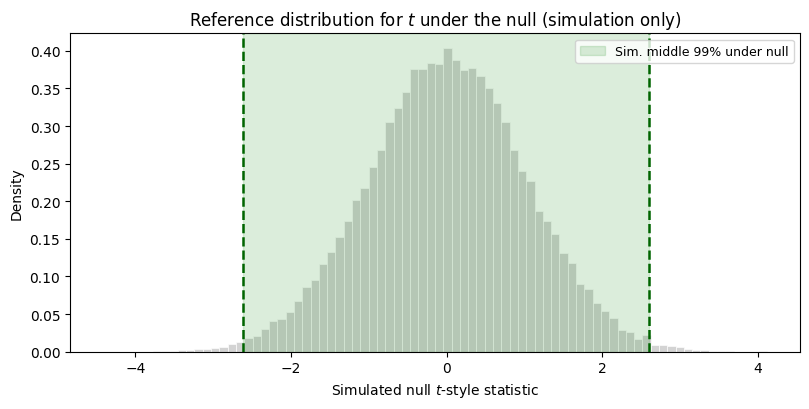

In [14]:
def standard_error(y_true, y_pred, n_params=2):
    rss = np.sum((y_true - y_pred) ** 2)
    return np.sqrt(rss / (len(y_true) - n_params))


def one_sample_slope_t(rng, sample_size):
    x = -1.0 + 1.0 * rng.random(sample_size)
    y = rng.standard_normal(sample_size)
    X = np.column_stack([np.ones(sample_size), x])
    beta = np.linalg.inv(X.T @ X) @ X.T @ y
    skk = np.linalg.inv(X.T @ X)[1, 1]
    s = standard_error(y, X @ beta)
    se_slope = np.sqrt((s**2) * skk)
    return beta[1] / se_slope


SAMPLE_SIZE = 100
TRIALS = 35_000
rng_t = np.random.default_rng(7)
t_stats = np.array([one_sample_slope_t(rng_t, SAMPLE_SIZE) for _ in range(TRIALS)])

# Quantiles = cutoff values on the sorted null t's: ~0.5% below q_lo, ~0.5% above q_hi, ~99% between.
q_lo, q_hi = np.quantile(t_stats, [0.005, 0.995])
print(f"Simulated null t quantiles: 0.5% -> {q_lo:.3f}, 99.5% -> {q_hi:.3f}")
print("Roughly 99% of null t's fall between these two lines (middle band).")

fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.hist(t_stats, bins=80, density=True, color="lightgray", edgecolor="white", linewidth=0.45)
ax.axvspan(q_lo, q_hi, color="green", alpha=0.14, label="Sim. middle 99% under null")
ax.axvline(q_lo, color="darkgreen", ls="--", lw=1.8)
ax.axvline(q_hi, color="darkgreen", ls="--", lw=1.8)
ax.set_xlabel(r"Simulated null $t$-style statistic")
ax.set_ylabel("Density")
ax.set_title("Reference distribution for $t$ under the null (simulation only)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

### Step 9 — **Fixed real $x$**: worksheet data, **resampled noise** $y$

Now we match a typical inference setup: the **$x$** values are **fixed** (the design you actually ran). Under the **null**, $y$ is **only** noise (no linear signal in expectation).

We compute the **observed** $t$-style statistic once from the real $(x,y)$. Then we **simulate** the null by keeping **the same $x$**, drawing **new** $y$ over and over, refitting each time.

**Coral** = simulated null $t$’s at least as extreme as observed (**two-sided**). The subtitle gives the **simulated p-value**.

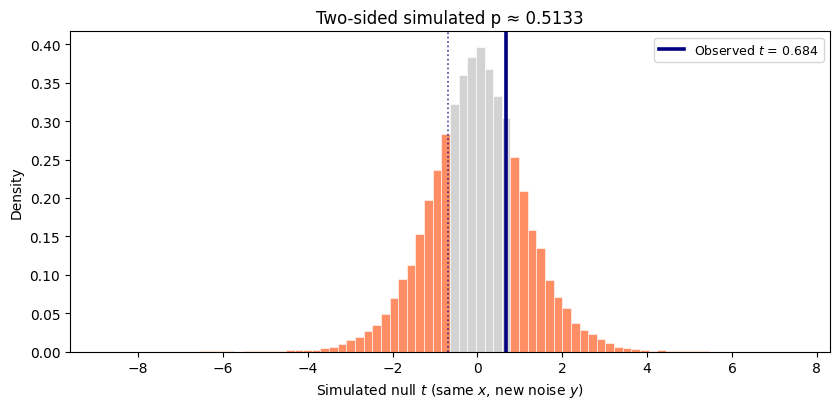

OLS slope estimate: 1.19902827199062
Observed t-style statistic: 0.6842586696389722
Simulated two-sided p-value: 0.51328


In [15]:
x = np.array(
    [
        -0.1920605,
        -0.11290798,
        -0.56434374,
        -0.67052057,
        -0.19233284,
        -0.42403586,
        -0.8114285,
        -0.38986946,
        -0.37384161,
        -0.50930229,
    ]
)
y = np.array(
    [
        -0.34063108,
        -0.33409286,
        0.34245857,
        0.11062295,
        0.76682389,
        0.86592388,
        -1.68912015,
        -2.01463592,
        1.61798563,
        0.60557414,
    ]
)

X = np.column_stack([np.ones(len(x)), x])
beta_hat_d = np.linalg.inv(X.T @ X) @ X.T @ y
s = standard_error(y, X @ beta_hat_d)
inv_xt_x = np.linalg.inv(X.T @ X)
se_slope = np.sqrt((s**2) * inv_xt_x[1, 1])
t_obs = beta_hat_d[1] / se_slope

N_T = 50_000
rng_td = np.random.default_rng(99)
t_null_d = np.empty(N_T)
for i in range(N_T):
    y_sim = rng_td.standard_normal(len(x))
    b = np.linalg.inv(X.T @ X) @ X.T @ y_sim
    s_sim = standard_error(y_sim, X @ b)
    se_b = np.sqrt((s_sim**2) * inv_xt_x[1, 1])
    t_null_d[i] = b[1] / se_b

mask_t = np.abs(t_null_d) >= np.abs(t_obs)
p_sim_t = mask_t.mean()

fig, ax = plt.subplots(figsize=(8.5, 4.2))
counts, edges, patches = ax.hist(
    t_null_d, bins=80, density=True, color="lightgray", edgecolor="white", linewidth=0.45
)
centers = 0.5 * (edges[:-1] + edges[1:])
for patch, c in zip(patches, centers):
    if abs(c) >= abs(t_obs):
        patch.set_facecolor("coral")
        patch.set_alpha(0.88)

ax.axvline(t_obs, color="navy", lw=2.6, label=rf"Observed $t$ = {t_obs:.3f}")
ax.axvline(-t_obs, color="navy", lw=1.2, ls=":", alpha=0.75)
ax.set_xlabel(r"Simulated null $t$ (same $x$, new noise $y$)")
ax.set_ylabel("Density")
ax.set_title(f"Two-sided simulated p ≈ {p_sim_t:.4f}")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

print("OLS slope estimate:", float(beta_hat_d[1]))
print("Observed t-style statistic:", float(t_obs))
print("Simulated two-sided p-value:", float(p_sim_t))

#### Same reference, two stories (p-value vs quantiles)

**Step 9** just used **coral tails** and a **simulated two-sided p-value** for the worksheet $t$: “how much null mass is **at least as extreme** as what we saw?”

**Step 8** used the **same kind of object**—a histogram of null $t$-style values—but summarized it with **quantiles**: two cutoffs so that **about 99%** of the null sims fall **between** them.

Both are views of a **simulated reference distribution**. **Hypothesis tests** emphasize **tails beyond the data**; **confidence intervals** (Part 3) emphasize **quantiles** that bracket a **middle fraction** of a reference tied to an **estimator**.

### Step 10 — **Visual check:** is the observed $t$ “inside typical null noise”?

Using the **same worksheet null simulation** as Step 9 (`t_null_d`), we mark the **simulated** middle 99% band with **quantiles** (green)—same cutoff idea as Step 8, applied to this dataset’s null cloud. If your observed $t$ lands **inside**, the data look **compatible** with the null story (at least in this rough visual sense). If it lands **outside**, it is **rare** under the null simulation.

This is the same logic as Part 1: **reference distribution + extreme tails**—just with a different statistic.

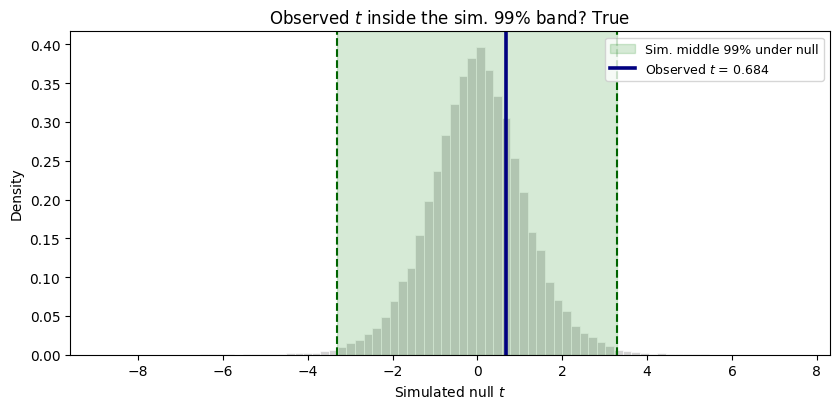

Simulated 99% null interval for t: [-3.3091, 3.2926]


In [16]:
q_lo_d, q_hi_d = np.quantile(t_null_d, [0.005, 0.995])
inside = q_lo_d <= t_obs <= q_hi_d

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.hist(t_null_d, bins=80, density=True, color="lightgray", edgecolor="white", linewidth=0.45)
ax.axvspan(q_lo_d, q_hi_d, color="green", alpha=0.16, label="Sim. middle 99% under null")
ax.axvline(q_lo_d, color="darkgreen", ls="--", lw=1.5)
ax.axvline(q_hi_d, color="darkgreen", ls="--", lw=1.5)
ax.axvline(t_obs, color="navy", lw=2.6, label=rf"Observed $t$ = {t_obs:.3f}")
ax.set_xlabel(r"Simulated null $t$")
ax.set_ylabel("Density")
ax.set_title(f"Observed $t$ inside the sim. 99% band? {inside}")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Simulated 99% null interval for t: [{q_lo_d:.4f}, {q_hi_d:.4f}]")

---

## Part 3 — Confidence intervals: a **process** with a long-run guarantee

A **confidence interval** is easy to misread. One interval from one dataset is **not** “there is a 95% chance $\mu$ is inside.” The useful meaning is **frequentist**:

> If we **repeat the same recipe** (same sample size, same formula) over and over, then in the **long run** a chosen fraction of intervals (e.g. 95%) will **contain** the true parameter.

**Link back:** Part 1 and **Step 9** stressed **p-values** (tail area under a simulated null). **Step 8** and the **Bridge** above introduced **quantiles** (cutoffs that trap a **middle** fraction of the same kind of reference). CIs use that quantile picture for a **parameter**, with a **long-run coverage** story.

We build that intuition in three small steps:

1. **Known** normal SD $\sigma$ — cleanest picture.  
2. **Centering** — why the interval is anchored at the **sample mean**, not an arbitrary number.  
3. **Unknown** $\sigma$ — we estimate spread from the data; intervals get a bit **wider** on average, but the **coverage** recipe can still work.

### Step 1 — Mean of a normal, **known** $\sigma$: watch coverage pile up

Assume $X_1,\ldots,X_n$ are i.i.d. $\mathcal{N}(\mu, \sigma^2)$ and $\sigma$ is **known** (toy classroom world).

A common **95% CI recipe** for $\mu$ is
$$
\bar X \pm z_{0.975}\,\frac{\sigma}{\sqrt{n}},
$$
where $\bar X$ is the sample mean and $z_{0.975}$ is the 97.5th percentile of the standard normal (we use `scipy.stats.norm.ppf` once so we do not need a magic number).

**Simulation:** draw many samples, build one interval per sample, and check whether the **fixed** true $\mu$ falls inside. The fraction of “hits” should be **close to 95%**.

The plot shows the **first 50** intervals as horizontal segments: **green** = captured $\mu$, **red** = missed (rare). The vertical line is the true $\mu$.

In [ ]:
from scipy.stats import norm

rng_ci = np.random.default_rng(202607)

mu_true = 50.0
sigma_known = 12.0
n = 40
alpha = 0.05
z_crit = norm.ppf(1 - alpha / 2)
half_width = z_crit * sigma_known / np.sqrt(n)

N_TRIALS = 4000
intervals = []
hits = 0
for _ in range(N_TRIALS):
    x = rng_ci.normal(mu_true, sigma_known, size=n)
    xbar = x.mean()
    lo = xbar - half_width
    hi = xbar + half_width
    intervals.append((lo, hi))
    hits += lo <= mu_true <= hi

coverage = hits / N_TRIALS
print(f"True mean mu = {mu_true}")
print(f"Known sigma = {sigma_known}, n = {n}, nominal level = {100*(1-alpha):.0f}%")
print(f"Empirical coverage over {N_TRIALS} intervals: {coverage:.4f}")

SHOW = 50
fig, ax = plt.subplots(figsize=(8, 5.5))
for i, (lo, hi) in enumerate(intervals[:SHOW]):
    ok = lo <= mu_true <= hi
    ax.plot([lo, hi], [i, i], color="seagreen" if ok else "crimson", lw=2.2, solid_capstyle="round")
ax.axvline(mu_true, color="black", lw=2.5, label=rf"true $\mu$ = {mu_true}")
ax.set_yticks([])
ax.set_xlabel(r"Interval on $\mu$ (each row is one repeated study)")
ax.set_title(f"First {SHOW} intervals: green = hit, red = miss")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Step 2 — **Centering:** why we anchor at $\bar X$, not an arbitrary constant

The **width** $\pm z\,\sigma/\sqrt{n}$ is only half the recipe. The interval must be placed where the data say the mean probably lies—**centered at $\bar X$** (our unbiased estimator of $\mu$).

Pick any **arbitrary** anchor $c$ that ignores the sample (example: $c = 0$ while the truth is $\mu = 50$). Using the **same** half-width but sliding the interval to sit around $c$ is **not** a valid 95% CI for $\mu$: long-run coverage collapses toward **zero**.

**Takeaway:** a CI is “$\text{estimate} \pm \text{margin}$”. Change the center away from a sensible estimate and you break the frequency guarantee—even if the margin *looks* reasonable.

In [ ]:
# Same mu_true, sigma_known, n, z_crit, half_width as Step 1
c_arbitrary = 0.0  # deliberately silly when mu_true = 50

hits_centered = 0
hits_arbitrary = 0
N2 = 8000
for _ in range(N2):
    x = rng_ci.normal(mu_true, sigma_known, size=n)
    xbar = x.mean()
    lo_c, hi_c = xbar - half_width, xbar + half_width
    lo_a, hi_a = c_arbitrary - half_width, c_arbitrary + half_width
    hits_centered += lo_c <= mu_true <= hi_c
    hits_arbitrary += lo_a <= mu_true <= hi_a

print("Centered at sample mean X_bar:")
print(f"  empirical coverage ≈ {hits_centered / N2:.4f}")
print(f"Centered at arbitrary c = {c_arbitrary} (same half-width):")
print(f"  empirical coverage ≈ {hits_arbitrary / N2:.4f}")

fig, ax = plt.subplots(figsize=(8, 4.2))
for i in range(25):
    x = rng_ci.normal(mu_true, sigma_known, size=n)
    xbar = x.mean()
    lo_a = c_arbitrary - half_width
    hi_a = c_arbitrary + half_width
    ok = lo_a <= mu_true <= hi_a
    ax.plot([lo_a, hi_a], [i, i], color="mediumpurple", lw=2, alpha=0.9)
ax.axvline(mu_true, color="black", lw=2.5, label=rf"true $\mu$ = {mu_true}")
ax.axvline(c_arbitrary, color="orange", ls="--", lw=2, label=rf"arbitrary center $c$ = {c_arbitrary}")
ax.set_yticks([])
ax.set_xlabel(r"$\mu$")
ax.set_title("25 intervals with correct width but **wrong** center — almost all miss")
ax.legend()
plt.tight_layout()
plt.show()

### Step 3 — **Unknown** $\sigma$: estimate spread from the data ($s$) and use $t$

In practice $\sigma$ is unknown. We replace $\sigma$ by the sample standard deviation $s$ (with divisor $n-1$) and replace $z$ by a slightly larger **$t$** critical value (fatter tails, accounting for “we guessed the spread”).

Recipe for a **95% CI** (normal data, unknown $\sigma$):
$$
\bar X \pm t_{0.975,\,n-1}\,\frac{s}{\sqrt{n}}.
$$

We **simulate** again: coverage should still land near **95%** in the long run, but individual intervals are **wider on average** than when $\sigma$ was known (more uncertainty).

Below we also print the **average half-width** under known-$\sigma$ $z$ vs unknown-$t$ for the same $n$ and true data-generating process.

In [ ]:
from scipy.stats import norm, t

n_t = 25
df = n_t - 1
t_crit = t.ppf(1 - alpha / 2, df)
z_for_compare = norm.ppf(1 - alpha / 2)
half_z_known = z_for_compare * sigma_known / np.sqrt(n_t)

N3 = 5000
hits_t = 0
widths_t = []
widths_z_if_sigma_known = []
for _ in range(N3):
    x = rng_ci.normal(mu_true, sigma_known, size=n_t)
    xbar = x.mean()
    s = x.std(ddof=1)
    hw_t = t_crit * s / np.sqrt(n_t)
    lo, hi = xbar - hw_t, xbar + hw_t
    widths_t.append(hw_t)
    widths_z_if_sigma_known.append(half_z_known)
    hits_t += lo <= mu_true <= hi

print(f"n = {n_t}, unknown-sigma recipe (t), nominal {100*(1-alpha):.0f}%")
print(f"Empirical coverage: {hits_t / N3:.4f}")
print(f"Average half-width with t and s: {np.mean(widths_t):.4f}")
print(f"Half-width if we magically knew sigma (z): {half_z_known:.4f}  (fixed; usually narrower than average t-interval)")

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(widths_t, bins=45, density=True, color="steelblue", alpha=0.85, edgecolor="white", label="Half-width: t · s / sqrt(n)")
ax.axvline(half_z_known, color="orange", lw=2.5, label="Half-width if sigma known (z)")
ax.set_xlabel("Half-width of one-sample CI")
ax.set_ylabel("Density")
ax.set_title("Unknown sigma: random s makes random interval width")
ax.legend()
plt.tight_layout()
plt.show()

### Part 3 wrap — how to say it in words

- A **confidence level** (e.g. 95%) is a promise about a **procedure** repeated many times, not a probability that “$\mu$ is in *this* interval” on a single run.  
- The interval **tracks** the data through **centering** at $\bar X$.  
- When $\sigma$ is unknown, we **pay a width tax** (through $s$ and $t$) but we can keep the **long-run hit rate** near the nominal level if the model is right.

## Takeaways (read me last)

- **Classroom:** null story → simulate many outcomes → **color** extremes → **simulated p-value** = fraction in the tail.
- **Regression:** null story → many datasets → **histogram of $\hat\beta_1$** or **$t$** → same tail idea.
- **Animations** showed two bridges: (1) **cloud + line** wiggling under the null, and (2) **slopes stacking** into a reference shape.
- When you learn the **formulas** later, they are shortcuts for curves that **simulations** would trace out anyway—here you built the picture with your eyes first.
- **Confidence intervals (Part 3):** a **level** is a long-run **hit rate** for a **recipe**; center at the **estimate** ($\bar X$); unknown $\sigma$ forces **$s$** and **$t$** and typically **wider** intervals with similar nominal coverage.
